In [ ]:
plt.close()
lw = 2
fs = 18
tw = 1
tl = 5

dM_list = [0.3, 1.3, 2.3, 3.3]
colors = ['blue','green','orange','red']

start = [7., np.log10(1.4*10**4.)]
stop = [12., np.log10(1.4*10**9.)]

fig = plt.figure(figsize=(12,10))

for dM, c in zip(dM_list, colors):
    qlf.get_SMBM(dM)
    massc = qlf.mass_cuts
    slopes = qlf.slope_list
    ints = qlf.int_list
    if massc[1] >= stop[0]:
        plt.plot([10**start[0], 10**massc[0]], [10**start[1], 10**(massc[0]*slopes[0]+ints[0])], c=c, lw = lw, label=r'dM = $10^{'+str(dM)+'}$ M$_{\odot}$')
        plt.plot([10**massc[0], 10**stop[0]], [10**(massc[0]*slopes[1]+ints[1]), 10**stop[1]], ls = 'dashed', lw = lw, c=c)
    else:
        plt.plot([10**massc[0], 10**massc[1]], [10**(massc[0]*slopes[1]+ints[1]), 10**(massc[1]*slopes[1]+ints[1])], ls = 'dashed', lw = lw, c=c)
        plt.plot([10**start[0], 10**massc[0]], [10**start[1], 10**(massc[0]*slopes[0]+ints[0])], c=c, lw = lw, label=r'dM = $10^{'+str(dM)+'}$ M$_{\odot}$')
        plt.plot([10**massc[1], 10**stop[0]], [10**(massc[1]*slopes[2]+ints[2]), 10**stop[1]], c=c, lw = lw)

plt.tick_params(direction='out', width = tw, length = tl, right = True, labelsize = fs)
plt.axvline(10**10.3, lw = 1.5, ls = 'dotted', c='grey')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'M$_{*}$/M$_{\odot}$', fontsize = fs)
plt.ylabel(r'M$_{\rm{BH}}$/M$_{\odot}$', fontsize = fs)
plt.legend(fontsize = fs)
plt.tight_layout()

/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/figure.py:2267: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "


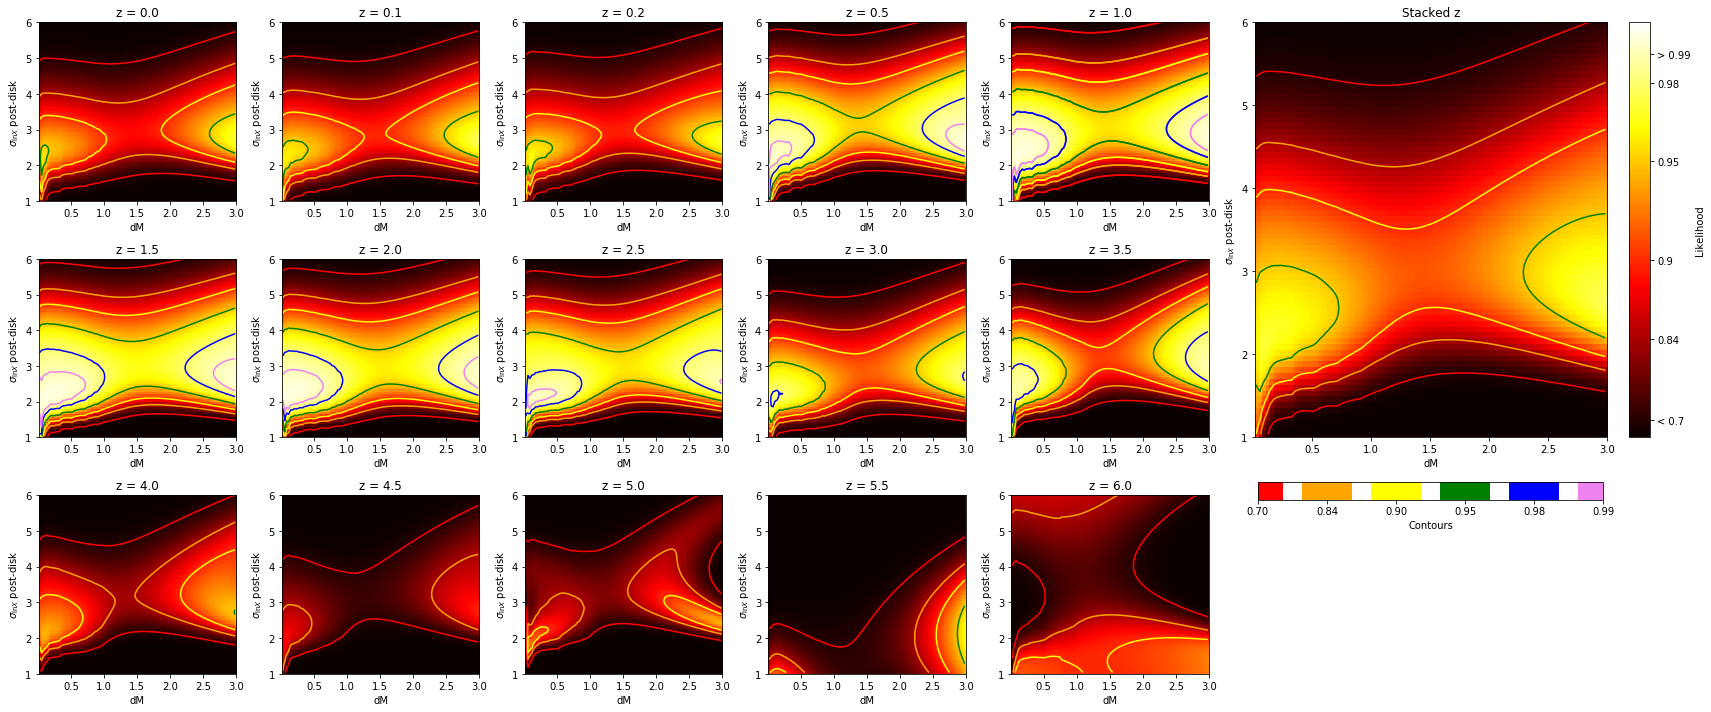

In [33]:
plt.close()

ticks = [0.70,0.84,0.90,0.95,0.98,0.99]
ticklabels = [str(i) for i in ticks]
ticklabels[0] = '< '+ticklabels[0]
ticklabels[-1] = '> '+ticklabels[-1]

gridcmap = 'hot'
contcmap = 'Pastel1'
contmin = 0.7
colors = ['red','orange','yellow','green','blue','violet']

f = h5py.File("Quest-emcee/chi2_grid_data_obsfix.h5py", "r")
extent = f['extent'][:]
bins = f.attrs['bins']
f.close()

totpoints = 732

fig = plt.figure(figsize=(24,10))
gs = gridspec.GridSpec(3, 7)
stack = np.zeros((bins, bins))
zlist = [0.0, 0.1, 0.2, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]
for z, i, j in zip(zlist,[0,0,0,0,0,1,1,1,1,1,2,2,2,2,2],[0,1,2,3,4,0,1,2,3,4,0,1,2,3,4]):
    
    
    xa, ya, yerr = grab_obs(z)
    num_obs = len(xa)
    f = h5py.File("Quest-emcee/chi2_grid_data_obsfix.h5py", "r")
    grid2d = f['z='+str(z)+'/chi2_grid'][:]
    maxval = f['z='+str(z)+'/min-max'][:][1]
    numob = f['z='+str(z)+'/#_observation'][:][0]
    f.close()

    ax = fig.add_subplot(gs[i, j])
    maxl = []
    for n in grid2d:
        maxl.append(max(n))
    maxval = max(maxl)
    img = ax.imshow(np.e**(-grid2d/maxval), cmap = gridcmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=5), vmin = .36, vmax = 1)
    ax.set_ylabel(r'$\sigma_{\ln{X}}$ post-disk')
    ax.set_xlabel('dM')
    ax.axis([0.01,3,1,6])
    ax.set_title('z = '+str(z))
#     plt.contour(np.e**(-grid2d/maxval), cmap=contcmap, extent = extent, origin = 'image', levels=ticks, vmin = contmin)
    plt.contour(np.e**(-grid2d/maxval), colors=colors, extent = extent, origin = 'image', levels=ticks)
    if z == 1.0:
#         cont1 = plt.contour(np.e**(-grid2d/maxval), cmap=contcmap, extent = extent, origin = 'image', levels=ticks, vmin = contmin)
        cont1 = plt.contour(np.e**(-grid2d/maxval), colors=colors, extent = extent, origin = 'image', levels=ticks)

    stack += np.e**(-grid2d/maxval) * (numob/totpoints)

    

ax1 = fig.add_subplot(gs[0:2,5:])

total = ax1.imshow(stack, cmap = gridcmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=5), vmin = .36, vmax = 1)
ax1.set_ylabel(r'$\sigma_{\ln{X}}$ post-disk')
ax1.set_xlabel('dM')
ax1.axis([0.01,3,1,6])
ax1.set_title('Stacked z')


cbar = plt.colorbar(total, label=r'Likelihood', pad = 0.05, ticks = ticks)
cbar.ax.set_yticklabels(ticklabels)
# cont = ax1.contour(stack, cmap=contcmap, extent = extent, origin = 'image', levels=ticks, vmin = contmin)
cont = ax1.contour(stack, colors=colors, extent = extent, origin = 'image', levels=ticks)
axx1 = plt.axes([.73, .3, .2, .025])
cbar = plt.colorbar(cont1, cax = axx1, ticks = ticks, orientation='horizontal', label='Contours')

lines = cbar.ax.get_children()[0]
lines.set_linewidths([50]*len(lines.get_linewidths()))

plt.tight_layout()

In [17]:
plt.close()

ticks = [0.70,0.90,0.925,0.95,0.975,0.99]
ticklabels = [str(i) for i in ticks]
ticklabels[0] = '< '+ticklabels[0]
ticklabels[-1] = '> '+ticklabels[-1]

gridcmap = 'hot'
contcmap = 'Pastel1'
contmin = 0.7
colors = ['red','orange','yellow','green','blue','violet']
gam=8

f = h5py.File("QUEST/data/chi2_2equiweight.h5py", "r")
dM = f['dM'][:]
siglnX2 = f['siglnX2'][:]
f.close()

extent = [dM[0], dM[-1], siglnX2[-1], siglnX2[0]]

totpoints = 732

fig = plt.figure(figsize=(24,10))
gs = gridspec.GridSpec(3, 7)
stack = np.zeros((len(dM), len(dM)))
zlist = [0.0, 0.1, 0.2, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]
for z, i, j in zip(zlist,[0,0,0,0,0,1,1,1,1,1,2,2,2,2,2],[0,1,2,3,4,0,1,2,3,4,0,1,2,3,4]):
    
    
    xa, ya, yerr = grab_obs(z)
    num_obs = len(xa)
    f = h5py.File("QUEST/data/chi2_2equiweight.h5py", "r")
    grid2d = np.transpose(f['z='+str(z)+'/chi2_grid'][:])
    numob = f['z='+str(z)+'/#_observation'][:][0]
    f.close()
    
    maxval = max(map(max, grid2d))

    ax = fig.add_subplot(gs[i, j])
    img = ax.imshow(np.e**(-grid2d/maxval), cmap = gridcmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=gam), vmin = .5, vmax = 1)
    ax.set_ylabel(r'$\sigma_{\ln{X}}$ post-disk')
    ax.set_xlabel('dM')
    ax.axis([0.01,3.3,1,6])
    ax.set_title('z = '+str(z))
    plt.contour(np.e**(-grid2d/maxval), colors=colors, extent = extent, origin = 'image', levels=ticks)
    if z == 1.0:
        cont1 = plt.contour(np.e**(-grid2d/maxval), colors=colors, extent = extent, origin = 'image', levels=ticks)

    stack += np.e**(-grid2d/maxval) * (numob/totpoints)

    

ax1 = fig.add_subplot(gs[0:2,5:])

total = ax1.imshow(stack, cmap = gridcmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=gam), vmin = .5, vmax = 1)
ax1.set_ylabel(r'$\sigma_{\ln{X}}$ post-disk')
ax1.set_xlabel('dM')
ax1.axis([0.01,3,1,6])
ax1.set_title('Stacked z')


cbar = plt.colorbar(total, label=r'Likelihood', pad = 0.05, ticks = ticks)
cbar.ax.set_yticklabels(ticklabels)
cont = ax1.contour(stack, colors=colors, extent = extent, origin = 'image', levels=ticks)
axx1 = plt.axes([.73, .3, .2, .025])
cbar = plt.colorbar(cont1, cax = axx1, ticks = ticks, orientation='horizontal', label='Contours')

lines = cbar.ax.get_children()[0]
lines.set_linewidths([50]*len(lines.get_linewidths()))

plt.tight_layout()

FigureCanvasNbAgg()

/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/figure.py:2267: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "


In [20]:
plt.close()

ticks = [0.70,0.90,0.925,0.95,0.975,0.99]
ticklabels = [str(i) for i in ticks]
ticklabels[0] = '< '+ticklabels[0]
ticklabels[-1] = '> '+ticklabels[-1]

gridcmap = 'hot'
contcmap = 'Pastel1'
contmin = 0.7
colors = ['red','orange','yellow','green','blue','violet']
gam=10

f = h5py.File("QUEST/data/chi2_2pShenfit.h5py", "r")
dM = f['dM'][:]
siglnX2 = f['siglnX2'][:]
f.close()

extent = [dM[0], dM[-1], siglnX2[-1], siglnX2[0]]

fig = plt.figure(figsize=(24,10))
gs = gridspec.GridSpec(3, 6)
stack = np.zeros((len(dM), len(dM)))
zlist = [0.2, 0.4, 0.8, 1.2, 1.8, 2.4, 3.0, 3.6, 4.2, 4.8, 5.4, 6.0]
for z, i, j in zip(zlist,[0,0,0,0,1,1,1,1,2,2,2,2],[0,1,2,3,0,1,2,3,0,1,2,3]):
    
    
    xa, ya, yerr = grab_obs(z)
    num_obs = len(xa)
    f = h5py.File("QUEST/data/chi2_2pShenfit.h5py", "r")
    grid2d = np.transpose(f['z='+str(z)+'/chi2_grid'][:])
    f.close()
    
    maxval = max(map(max, grid2d))

    ax = fig.add_subplot(gs[i, j])
    img = ax.imshow(np.e**(-grid2d/maxval), cmap = gridcmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=gam), vmin = .5, vmax = 1)
    ax.set_ylabel(r'$\sigma_{\ln{X}}$ post-disk')
    ax.set_xlabel('dM')
    ax.axis([0.01,3.3,1,5])
    ax.set_title('z = '+str(z))
    plt.contour(np.e**(-grid2d/maxval), colors=colors, extent = extent, origin = 'image', levels=ticks)
    if z == 1.2:
        cont1 = plt.contour(np.e**(-grid2d/maxval), colors=colors, extent = extent, origin = 'image', levels=ticks)

    stack += np.e**(-grid2d/maxval) * (1/len(zlist))

    

ax1 = fig.add_subplot(gs[0:2,4:])

total = ax1.imshow(stack, cmap = gridcmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=gam), vmin = .5, vmax = 1)
ax1.set_ylabel(r'$\sigma_{\ln{X}}$ post-disk')
ax1.set_xlabel('dM')
ax1.axis([0.01,3,1,5])
ax1.set_title('Stacked z')


cbar = plt.colorbar(total, label=r'Likelihood', pad = 0.05, ticks = ticks)
cbar.ax.set_yticklabels(ticklabels)
cont = ax1.contour(stack, colors=colors, extent = extent, origin = 'image', levels=ticks)
axx1 = plt.axes([.73, .3, .2, .025])
cbar = plt.colorbar(cont1, cax = axx1, ticks = ticks, orientation='horizontal', label='Contours')

lines = cbar.ax.get_children()[0]
lines.set_linewidths([50]*len(lines.get_linewidths()))

plt.tight_layout()

FigureCanvasNbAgg()

/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/figure.py:2267: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "


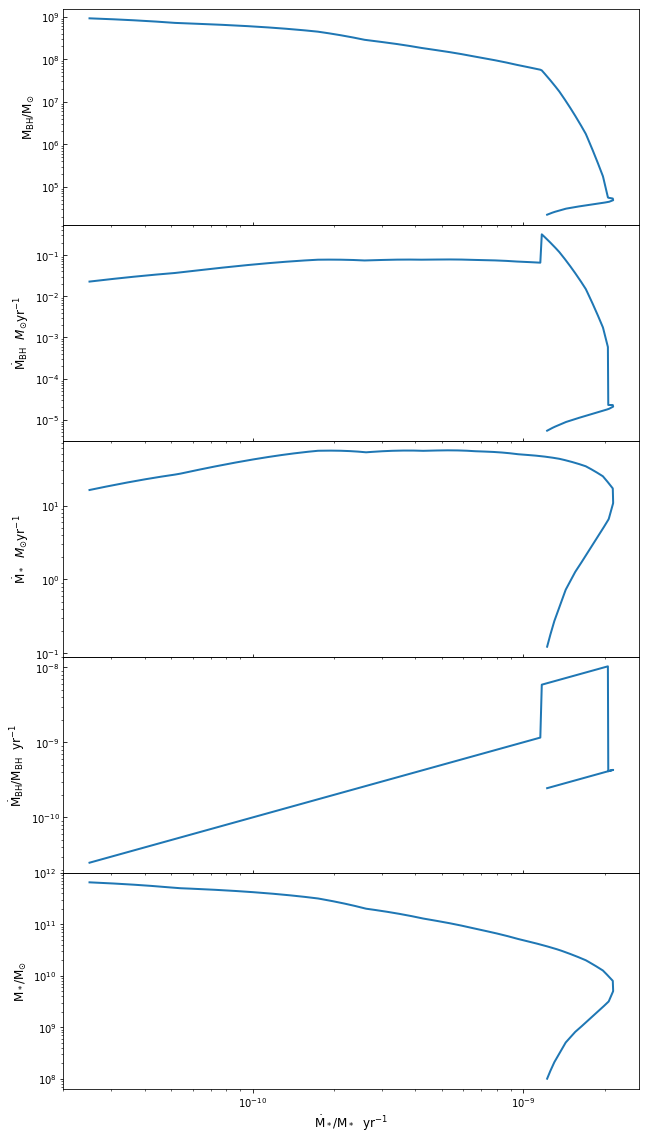

In [17]:
# qlf = QLF(1.5, 500)
# qlf.get_dNdlnMstar(0.7)
# qlf.get_SMBM(0.3)
# qlf.LumBins = np.linspace(6,18,1000)
# qlf.get_dNdlnL([5,3])
# MdotBH = np.e**(qlf.Mdot_mu_sig[:,3])/(3.17098e-8*2e33) ## Mdot yr-1
# MdotStar = np.e**qlf.Mdot_mu_sig[:,5] * 10**(qlf.StellBins)
# SSFR = np.e**qlf.Mdot_mu_sig[:,5]
# SBHR = np.e**qlf.Mdot_mu_sig[:,4] * 3.154e7
# Mbh = 10**(qlf.StellBins * qlf.m + qlf.b)
#Mstar = 10**qlf.StellBins

y_list1 = [SSFR, SBHR, MdotStar, MdotBH, Mbh]
x1, file1, xlabel1 = Mstar, 'Mstar', r'$\rmM_*/M_{\odot}$'
y_list2 = [SSFR, SBHR, MdotStar, MdotBH, Mstar]
x2, file2, xlabel2 = Mbh, 'Mbh', r'$\rmM_{\rmBH}/M_{\odot}$'
y_list3 = [SSFR, SBHR, MdotStar, Mstar, Mbh]
x3, file3, xlabel3 = MdotBH, 'MdotBH', r'$\dot{\rmM}_{\rmBH} \ \ M_{\odot} \rmyr^{-1}$'
y_list4 = [SSFR, SBHR, Mstar, MdotBH, Mbh]
x4, file4, xlabel4 = MdotStar, 'MdotStar', r'$\dot{\rmM}_* \ \ M_{\odot} \rmyr^{-1}$'
y_list5 = [SSFR, Mstar, MdotStar, MdotBH, Mbh]
x5, file5, xlabel5 = SBHR, 'SBHR', r'$\dot{\rmM}_{\rmBH}/\rmM_{\rmBH} \ \ \rmyr^{-1}$'
y_list6 = [Mstar, SBHR, MdotStar, MdotBH, Mbh]
x6, file6, xlabel6 = SSFR, 'SSFR', r'$\dot{\rmM}_*/\rmM_* \ \ \rmyr^{-1}$'

label_list1 = [r'$\dot{\rmM}_*/\rmM_* \ \ \rmyr^{-1}$', r'$\dot{\rmM}_{\rmBH}/\rmM_{\rmBH} \ \ \rmyr^{-1}$',\
              r'$\dot{\rmM}_* \ \ M_{\odot} \rmyr^{-1}$', r'$\dot{\rmM}_{\rmBH} \ \ M_{\odot} \rmyr^{-1}$', r'$\rmM_{\rmBH}/M_{\odot}$']
label_list2 = [r'$\dot{\rmM}_*/\rmM_* \ \ \rmyr^{-1}$', r'$\dot{\rmM}_{\rmBH}/\rmM_{\rmBH} \ \ \rmyr^{-1}$',\
              r'$\dot{\rmM}_* \ \ M_{\odot} \rmyr^{-1}$', r'$\dot{\rmM}_{\rmBH} \ \ M_{\odot} \rmyr^{-1}$', r'$\rmM_*/M_{\odot}$']
label_list3 = [r'$\dot{\rmM}_*/\rmM_* \ \ \rmyr^{-1}$', r'$\dot{\rmM}_{\rmBH}/\rmM_{\rmBH} \ \ \rmyr^{-1}$',\
              r'$\dot{\rmM}_* \ \ M_{\odot} \rmyr^{-1}$', r'$\rmM_*/M_{\odot}$', r'$\rmM_{\rmBH}/M_{\odot}$']
label_list4 = [r'$\dot{\rmM}_*/\rmM_* \ \ \rmyr^{-1}$', r'$\dot{\rmM}_{\rmBH}/\rmM_{\rmBH} \ \ \rmyr^{-1}$',\
              r'$\rmM_*/M_{\odot}$', r'$\dot{\rmM}_{\rmBH} \ \ M_{\odot} \rmyr^{-1}$', r'$\rmM_{\rmBH}/M_{\odot}$']
label_list5 = [r'$\dot{\rmM}_*/\rmM_* \ \ \rmyr^{-1}$', r'$\rmM_*/M_{\odot}$',\
              r'$\dot{\rmM}_* \ \ M_{\odot} \rmyr^{-1}$', r'$\dot{\rmM}_{\rmBH} \ \ M_{\odot} \rmyr^{-1}$', r'$\rmM_{\rmBH}/M_{\odot}$']
label_list6 = [r'$\rmM_*/M_{\odot}$', r'$\dot{\rmM}_{\rmBH}/\rmM_{\rmBH} \ \ \rmyr^{-1}$',\
              r'$\dot{\rmM}_* \ \ M_{\odot} \rmyr^{-1}$', r'$\dot{\rmM}_{\rmBH} \ \ M_{\odot} \rmyr^{-1}$', r'$\rmM_{\rmBH}/M_{\odot}$']

y_lists = [y_list1, y_list2, y_list3, y_list4, y_list5, y_list6,]
xs = [x1, x2, x3, x4, x5, x6]
files = [file1, file2, file3, file4, file5, file6]
xlabels = [xlabel1, xlabel2, xlabel3, xlabel4, xlabel5, xlabel6]
label_lists = [label_list1, label_list2, label_list3, label_list4, label_list5, label_list6]

lw = 2
fs = 12

for y_list, x, file, xlabel, label_list in zip(y_lists, xs, files, xlabels, label_lists):
    plt.close('all')
    fig = plt.figure(figsize=(10,20))

    ax1 = fig.add_axes([0.1, 0.1, 0.8, 0.15])
    ax2 = fig.add_axes([0.1, 0.25, 0.8, 0.15], sharex = ax1)
    ax3 = fig.add_axes([0.1, 0.4, 0.8, 0.15], sharex = ax1)
    ax4 = fig.add_axes([0.1, 0.55, 0.8, 0.15], sharex = ax1)
    ax5 = fig.add_axes([0.1, 0.70, 0.8, 0.15], sharex = ax1)
    for ax, y, label in zip([ax1, ax2, ax3, ax4, ax5], y_list, label_list):

        ax.plot(x, y, lw = lw)
        ax.set_ylabel(label, fontsize = fs)
        ax.set_yscale('log')
        ax.set_xscale('log')

        if ax != ax1:
            ax.tick_params(direction='in')
            plt.setp(ax.get_xticklabels(), visible=False)
        else:
            ax.set_xlabel(xlabel, fontsize = fs)

#     plt.savefig('plots/paper-plots/accretion_'+file+'.pdf')

10.600000000000001


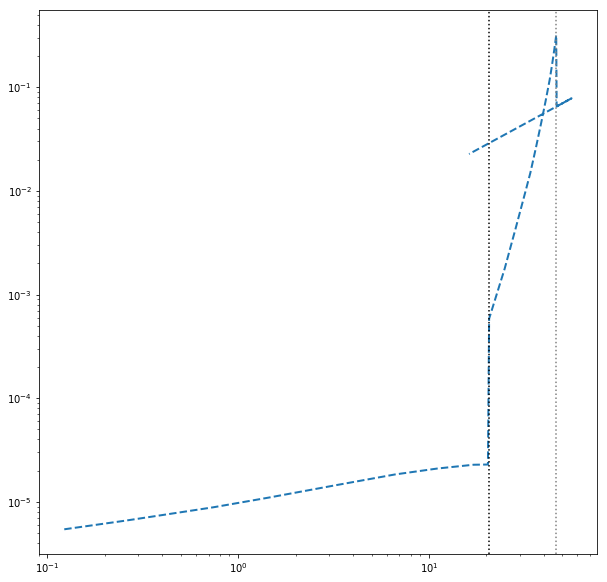

In [47]:
fig = plt.figure(figsize=(10,10))
qlf = QLF(1.5, 500)
qlf.get_dNdlnMstar(0.7)
qlf.get_SMBM(0.3)
qlf.LumBins = np.linspace(6,18,1000)
qlf.get_dNdlnL([5,3])
MdotBH = np.e**(qlf.Mdot_mu_sig[:,3])/(3.17098e-8*2e33) ## Mdot yr-1
MdotStar = np.e**qlf.Mdot_mu_sig[:,5] * 10**(qlf.StellBins)
SSFR = np.e**qlf.Mdot_mu_sig[:,5]
SBHR = np.e**qlf.Mdot_mu_sig[:,4] * 3.154e7
Mbh = 10**(qlf.StellBins * qlf.m + qlf.b)
Mstar = 10**qlf.StellBins
mass_cuts = qlf.mass_cuts
print(qlf.mass_cuts[1])
cut1 = np.argmin(np.abs(Mstar - 10**mass_cuts[0]))
cut2 = np.argmin(np.abs(Mstar - 10**mass_cuts[1]))


plt.plot(MdotStar, MdotBH, lw=2, linestyle='dashed')
plt.axvline(MdotStar[cut1], c='k', linestyle='dotted')
plt.axvline(MdotStar[cut2], c='gray', linestyle='dotted')
plt.xscale('log')
plt.yscale('log')

In [8]:
%matplotlib widget
fig = plt.figure(figsize=(22,4))
gs = gridspec.GridSpec(1, 4)
lums = np.linspace(5,18,1000)
z = 1.5
qlf = QLF(z, 0.01)
x, y , yerr = grab_obs(z)
lines = ['solid','dashed','dotted','dashdot']

ax = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1], sharex = ax, sharey = ax)
ax2 = fig.add_subplot(gs[0, 2], sharex = ax, sharey = ax)
ax3 = fig.add_subplot(gs[0, 3], sharex = ax, sharey = ax)
# ax4 = fig.add_subplot(gs[0, 4])

for dM, ls in zip([0.3, 1.7, 3.3], lines):
    qlf = QLF(z, 0.01)
    qlf.get_dNdlnMstar(0.7)
    qlf.get_SMBM(dM)
    qlf.get_dNdlnL(lums, [6.0, 2.5])
    xm, ym = lums, np.log10(qlf.dNdlnL * np.log(10))
    ax.plot(xm, ym, c='k', lw=1, label=r'dM = $10^{'+str(dM)+'}$ M$_{\odot}$', ls = ls)
    
    totearly = []
    totgrowth = []
    totlate = []

    for i, o in zip(qlf.intvals, qlf.FOb):
        totearly.append((1-o) * np.sum(i[qlf.early]))
        totgrowth.append((1-o) * np.sum(i[qlf.growth]))
        totlate.append((1-o) * np.sum(i[qlf.late]))
#     Mdotbh = qlf.Mdot_mu_sig[:,0]
    ax1.plot(xm, np.log10(np.asarray(totearly) * np.log(10)), c='r',lw=1, ls=ls, label=r'dM = $10^{'+str(dM)+'}$ M$_{\odot}$')
    ax2.plot(xm, np.log10(np.asarray(totgrowth) * np.log(10)), c='g',lw=1, ls=ls, label=r'dM = $10^{'+str(dM)+'}$ M$_{\odot}$')
    ax3.plot(xm, np.log10(np.asarray(totlate) * np.log(10)), c='b',lw=1, ls=ls, label=r'dM = $10^{'+str(dM)+'}$ M$_{\odot}$')
#     ax4.plot(np.log(np.e**Mdotbh/(3.17098e-8*2e33)), qlf.Mdot_mu_sig[:,1], lw=1, ls=ls, label=r'dM = $10^{'+str(dM)+'}$ M$_{\odot}$')
ax.errorbar(x, y, yerr = yerr, fmt = 'o', markersize = .15, c='gray', label = 'observed')
ax.legend(fontsize=14)
ax1.legend(fontsize=14)
ax2.legend(fontsize=14)
ax3.legend(fontsize=14)
# ax4.legend(fontsize=14)
ax.set_xlabel(r'$\log_{10} [L_{bol}/L_{\odot}]$', fontsize=14)
ax1.set_xlabel(r'$\log_{10} [L_{bol}/L_{\odot}]$', fontsize=14)
ax2.set_xlabel(r'$\log_{10} [L_{bol}/L_{\odot}]$', fontsize=14)
ax3.set_xlabel(r'$\log_{10} [L_{bol}/L_{\odot}]$', fontsize=14)
# ax4.set_xlabel(r'$\dot{\rmM}_{\rmBH}/\rmM_{\odot} $yr$^{-1}$', fontsize=14)
ax.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =14)
# ax4.set_ylabel(r'$\sigma_{\ln \rmX}$ (dex)')
ax.axis([6,16,-10,-3])




plt.setp(ax1.get_yticklabels(), visible=False)
plt.setp(ax2.get_yticklabels(), visible=False)
plt.setp(ax3.get_yticklabels(), visible=False)
plt.tight_layout()

FigureCanvasNbAgg()

/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:214: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:218: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:35: RuntimeWarning: divide by zero encountered in log10
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: divide by zero encountered in log10
